In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Overviewing Data

In [39]:
df=pd.read_csv('city_day.csv')

In [40]:
df.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
3391,Amritsar,2018-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN
11723,Delhi,2019-02-03,131.10,209.41,20.77,34.53,37.93,40.43,1.32,11.70,29.44,3.28,20.96,0.14,323.0,Very Poor
14908,Hyderabad,2015-11-27,83.12,115.67,7.20,16.36,21.79,8.93,1.10,9.12,33.04,1.58,6.92,0.78,172.0,Moderate
11883,Delhi,2019-07-13,63.18,294.27,11.09,23.13,22.98,28.61,0.97,9.11,30.81,1.92,18.59,0.07,312.0,Very Poor
11160,Delhi,2017-07-20,28.88,NaN,41.13,61.54,11.02,44.64,0.00,NaN,NaN,0.27,0.00,NaN,116.0,Moderate


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [42]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [43]:
print(f"Data covered from {df['Date'].min()} to {df['Date'].max()}")

Data covered from 2015-01-01 to 2020-07-01


# Stats

In [44]:
num_cols=df.select_dtypes(include=['float64']).columns
df_stats=df[num_cols].agg(['mean','median','var','std'])
df_stats.head(10)

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
median,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
var,4181.103046,8209.285907,519.194793,599.013182,1001.470008,659.681982,48.481757,328.833790,470.669909,249.992035,398.767497,39.983458,19795.529057
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585


## Missing values analysis

In [45]:
missing=df.isna().sum()
missing_perct=(missing/len(df))*100
missing=pd.DataFrame({'Missing data':missing , 'Missing %age':missing_perct})
missing.head(10)

,Missing data,Missing %age
City,0,0.000000
Date,0,0.000000
PM2.5,4598,15.570079
PM10,11140,37.723071
NO,3582,12.129626
NO2,3585,12.139785
NOx,4185,14.171549
NH3,10328,34.973418
CO,2059,6.972334
SO2,3854,13.050692


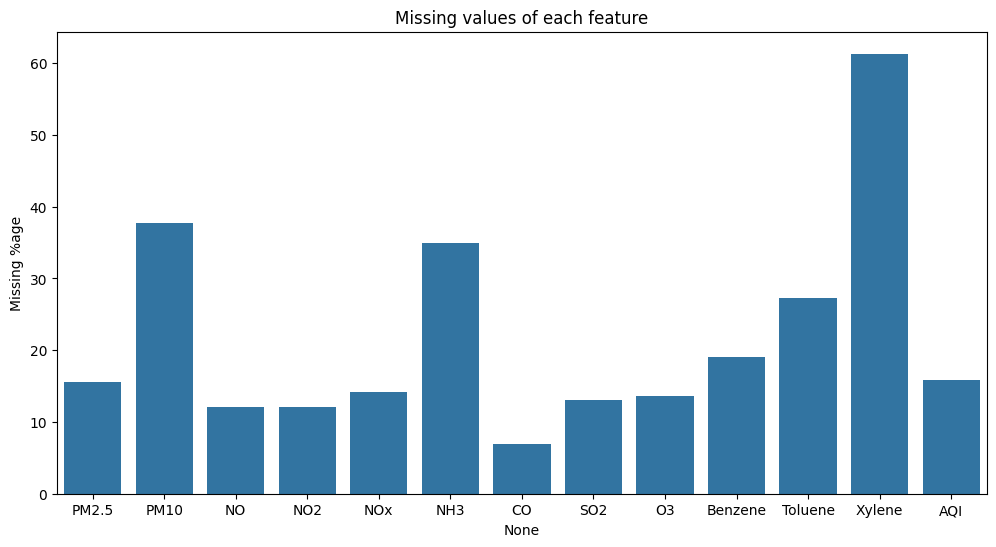

In [46]:
plt.figure(figsize=(12,6))
sns.barplot(x=missing.index[2:15],y=missing['Missing %age'][2:15])
plt.title("Missing values of each feature")
plt.show()

In [47]:
missing.mean()

Missing data    5530.500000
Missing %age      18.727778
dtype: float64

## EDA

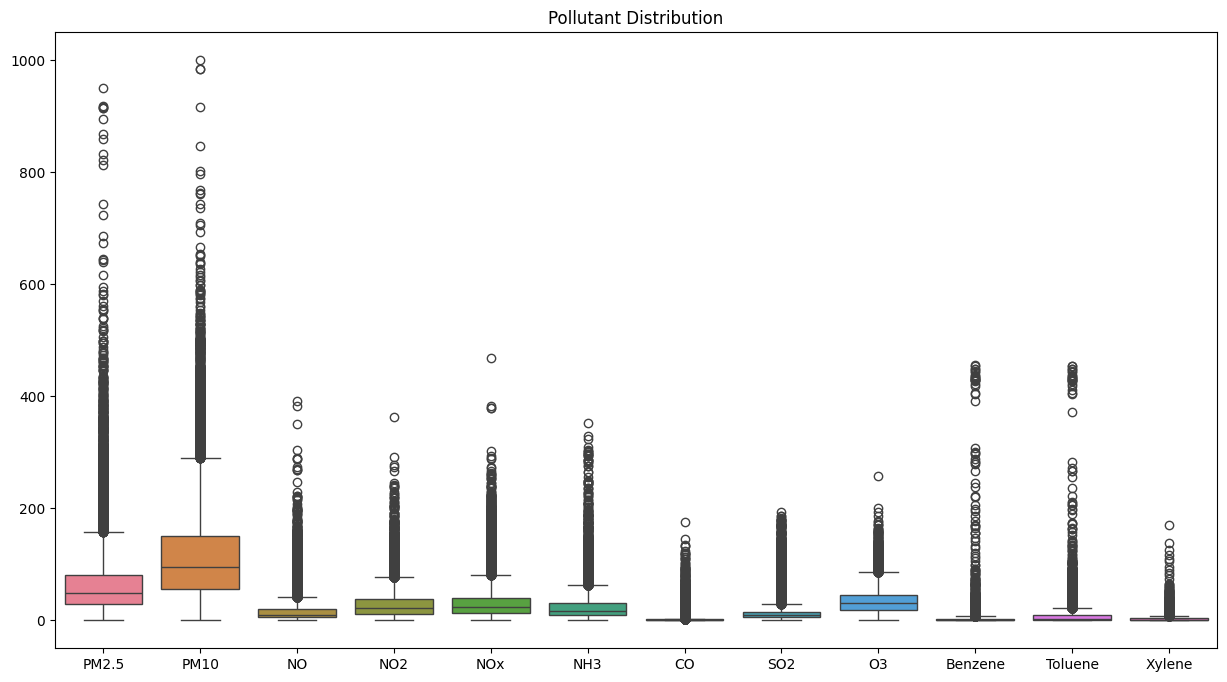

In [48]:
pollutants=['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']
plt.figure(figsize=(15,8))
sns.boxplot(data=df[pollutants])
plt.title('Pollutant Distribution')
plt.show()

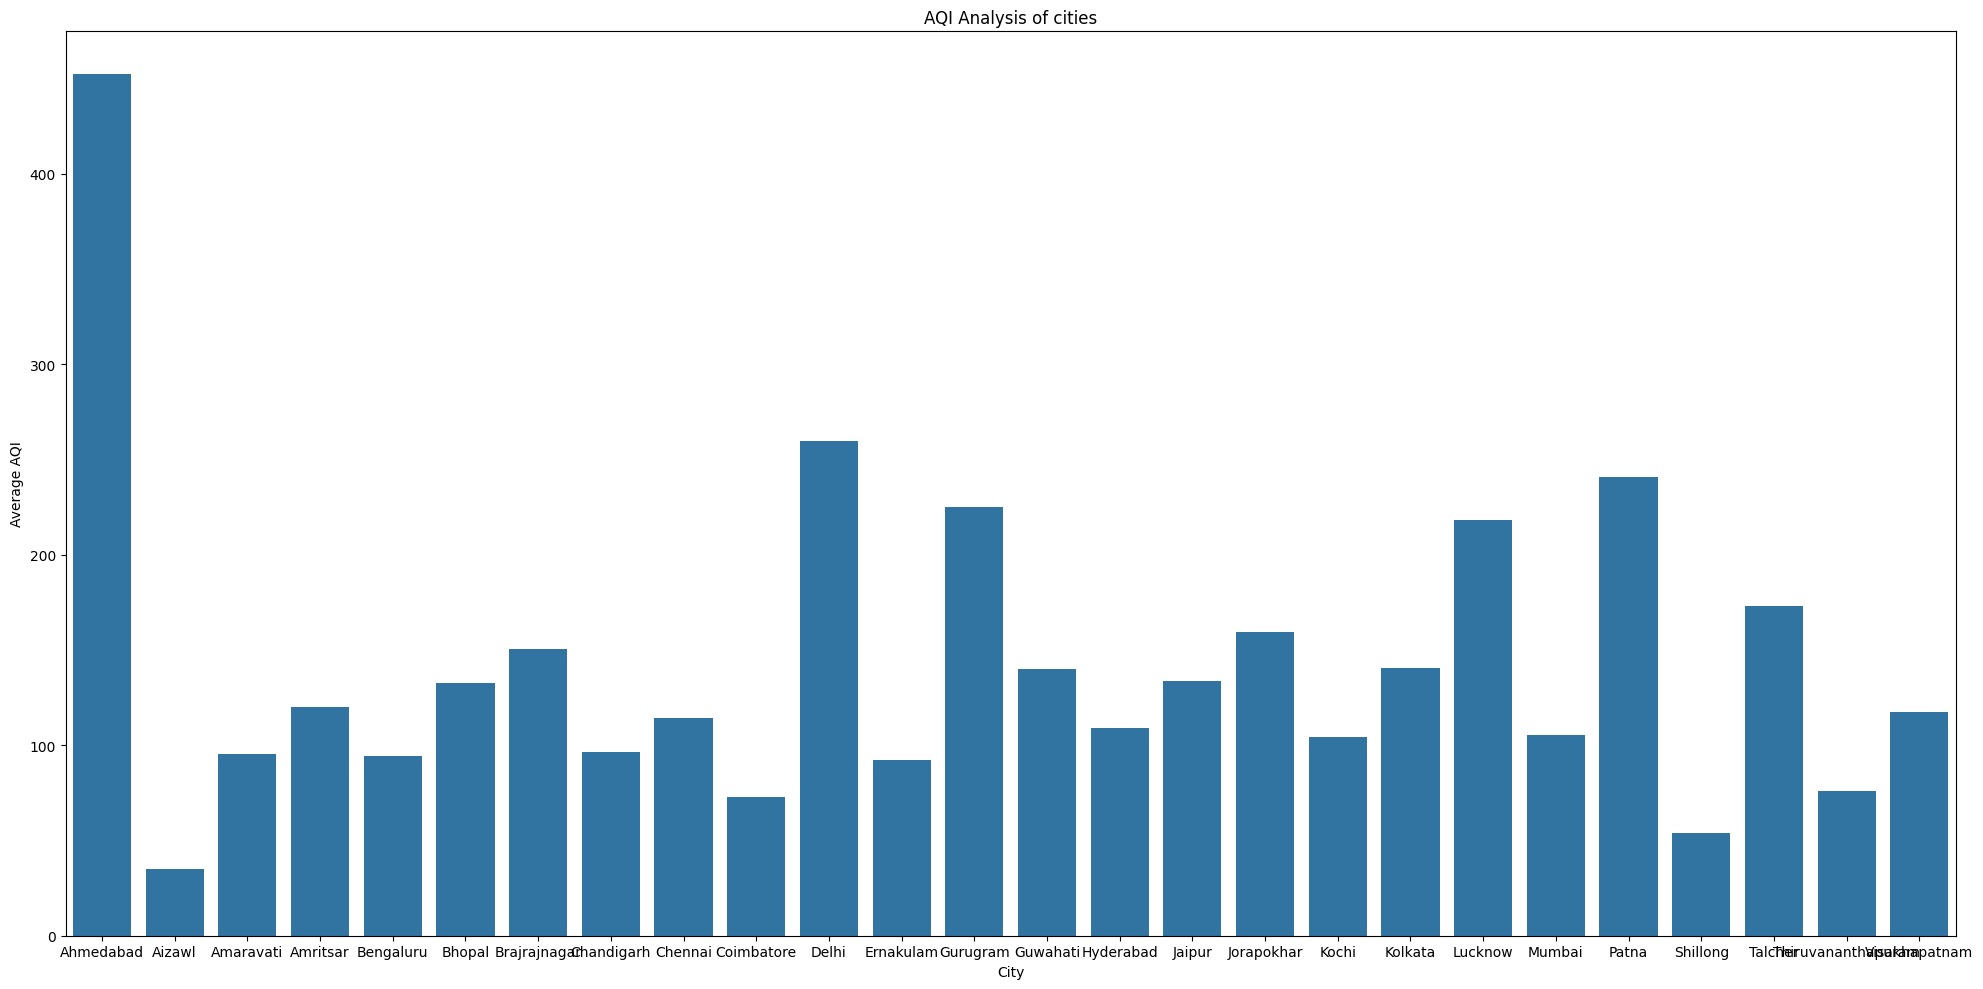

In [49]:
city_aqi=df.groupby('City')['AQI'].mean()
plt.figure(figsize=(20,10))
sns.barplot(x=city_aqi.index,y=city_aqi.values)
plt.title('AQI Analysis of cities')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

In [50]:
drop_cities = ['Aizawl', 'Shillong', 'Coimbatore', 'Thiruvananthapuram']
df = df[df['City'].isin(drop_cities) == False]

## Data Cleaning

In [51]:
print(f"The length of the data before cleaning is {len(df)}")
before=len(df)
df=df.drop_duplicates(subset=['City','Date'])
after=len(df)
if(before==after):
    print('No duplicates were present')
else:
    print(f"The length of the data after clearing duplicates is {len(df)}")

The length of the data before cleaning is 27610
No duplicates were present


In [52]:
missing

,Missing data,Missing %age
City,0,0.000000
Date,0,0.000000
PM2.5,4598,15.570079
PM10,11140,37.723071
NO,3582,12.129626
NO2,3585,12.139785
NOx,4185,14.171549
NH3,10328,34.973418
CO,2059,6.972334
SO2,3854,13.050692


In [53]:
df.drop('Xylene', axis=1, inplace=True) ## more than 50% missing values

In [54]:
## filling numeric cols with mean
df = df.sort_values(['City', 'Date'])

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df.groupby('City')[col].ffill().bfill()


In [55]:
df.isna().sum()

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
AQI              0
AQI_Bucket    4472
dtype: int64

In [56]:
## dropping missing targets
df['AQI_Bucket'] = df.groupby('City')['AQI_Bucket'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

In [57]:
print(df.columns)

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket'],
      dtype='object')


In [58]:
from sklearn.preprocessing import OrdinalEncoder

oe=OrdinalEncoder(categories=[['Good','Satisfactory','Moderate','Poor','Very Poor','Severe','Unknown']])
df['AQI_Bucket'] = oe.fit_transform(df[['AQI_Bucket']])

In [59]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,67.854497,114.584029,0.92,18.22,17.15,12.19,0.92,27.64,133.36,0.00,0.02,452.122939,5.0
1,Ahmedabad,2015-01-02,67.854497,114.584029,0.97,15.69,16.46,12.19,0.97,24.55,34.06,3.68,5.50,452.122939,5.0
2,Ahmedabad,2015-01-03,67.854497,114.584029,17.40,19.30,29.70,12.19,17.40,29.07,30.70,6.80,16.40,452.122939,5.0
3,Ahmedabad,2015-01-04,67.854497,114.584029,1.70,18.48,17.97,12.19,1.70,18.59,36.08,4.43,10.14,452.122939,5.0
4,Ahmedabad,2015-01-05,67.854497,114.584029,22.10,21.42,37.76,12.19,22.10,39.33,39.31,7.01,18.89,452.122939,5.0


## Feature Engineering

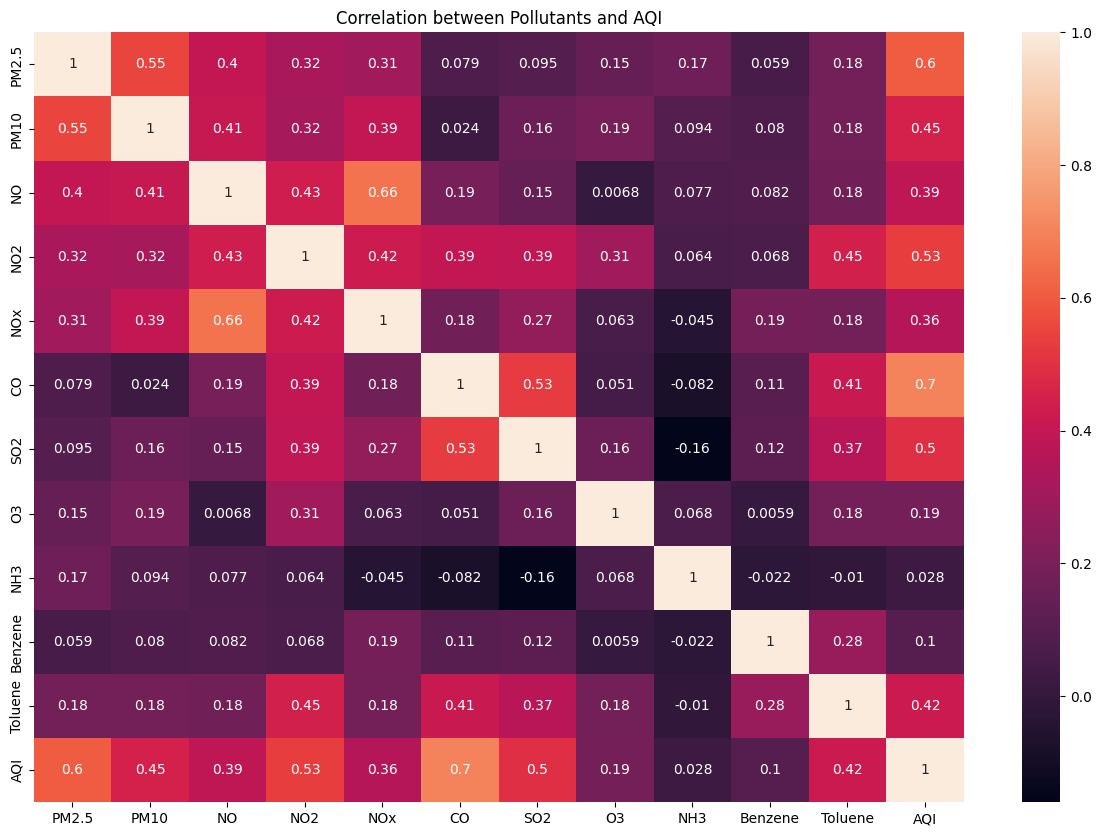

In [60]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','CO','SO2','O3','NH3','Benzene','Toluene']

plt.figure(figsize=(15,10))
sns.heatmap(df[pollutants + ['AQI']].corr(), annot=True)
plt.title("Correlation between Pollutants and AQI")
plt.show()

In [61]:
##extracting year,month,day from the Date col
df['Date'] = pd.to_datetime(df['Date'])

df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.dayofweek

In [62]:
lags = [1, 2, 3]
for col in pollutants:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df.groupby('City')[col].shift(lag)
lag= [f'{col}_lag{lag}' for col in pollutants for lag in lags]

windows = [3, 7, 14]
for col in pollutants:
    for w in windows:
        df[f'{col}_roll{w}'] = df.groupby('City')[col].transform(lambda x: x.rolling(window=w, min_periods=1).mean())
roll= [f'{col}_roll{w}' for col in pollutants for w in windows]

In [63]:
from sklearn.preprocessing import OneHotEncoder

city_encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids dummy variable trap
city_encoded = city_encoder.fit_transform(df[['City']])

city_encoded_df = pd.DataFrame(city_encoded, columns=city_encoder.get_feature_names_out(['City']))
df = pd.concat([df.reset_index(drop=True), city_encoded_df.reset_index(drop=True)], axis=1)

df = df.drop('City', axis=1)

In [64]:
df.sample(5)

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,City_Hyderabad,City_Jaipur,City_Jorapokhar,City_Kochi,City_Kolkata,City_Lucknow,City_Mumbai,City_Patna,City_Talcher,City_Visakhapatnam
5267,2017-12-22,71.710000,58.040000,11.41,142.35,77.93,37.00,0.95,3.320000,32.868086,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8265,2016-06-28,60.360000,62.834404,6.84,13.17,14.93,71.50,0.82,3.500000,28.090000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4359,2015-06-28,20.990000,83.243287,0.72,4.38,1.91,6.30,2.03,2.530000,15.420000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13911,2020-01-13,152.570000,240.560000,77.03,14.06,141.54,16.55,1.68,13.100000,18.180000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26075,2020-04-20,61.405425,47.790000,6.60,5.53,0.94,13.13,2.37,28.494789,69.650000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [65]:
city= city_encoded_df.columns.tolist()
pollutants=['PM2.5', 'PM10','NO', 'NO2', 'CO', 'SO2']
time=['Month','Year']

features = pollutants+time+lag+roll+city

In [66]:
df = df.dropna(subset=features + ['AQI', 'AQI_Bucket']).reset_index(drop=True)

In [67]:
X = df[features]          
y = df['AQI_Bucket']

## Model Evaluation

In [68]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model=LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred)*100)

Logistic Regression Accuracy: 74.07878017789072


In [71]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=10,random_state=42)
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred)*100)

Decision Tree Accuracy: 80.45017244508985


In [72]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(
    n_estimators=300,      
    max_depth=15,
    random_state=42
)
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred)*100)

Random Forest Accuracy: 84.11689961880559


In [73]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred) * 100)


XGBoost Accuracy: 85.89580686149937
